# Diccionario de datos
- transaction_id : Unique sequential ID representing an individual transaction
- transaction_date : Date of the transaction (MM/DD/YY)
- transaction_time : Timestamp of the transaction (HH:MM:SS)
- transaction_qty : Quantity of items sold
- store_id : Unique ID of the coffee shop where the transaction took place
- store_location : Location of the coffee shop where the transaction took place
- product_id : Unique ID of the product sold
- unit_price : Retail price of the product sold
- product_category : Description of the product category
- product_type : Description of the product type
- product_detail : Description of the product detail

# Carga y exploración de datos

In [1]:
# Librerias necesarias para el analisis de datos
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

In [216]:
# https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales/data
path = kagglehub.dataset_download("ahmedabbas757/coffee-sales")
print("Path to dataset files:", path)

df = pd.read_excel(path + "/Coffee Shop Sales.xlsx")
df

Using Colab cache for faster access to the 'coffee-sales' dataset.
Path to dataset files: /kaggle/input/coffee-sales


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [217]:
# Verificar si hay valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [218]:
print(df.describe())
# Variables categoricas
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Columnas categóricas:", categorical_cols)
# Variables numéricas
numeric_cols = df.select_dtypes(include=["number"]).columns
print("Columnas numéricas:", numeric_cols)

       transaction_id               transaction_date  transaction_qty  \
count   149116.000000                         149116    149116.000000   
mean     74737.371872  2023-04-15 11:50:32.173609984         1.438276   
min          1.000000            2023-01-01 00:00:00         1.000000   
25%      37335.750000            2023-03-06 00:00:00         1.000000   
50%      74727.500000            2023-04-24 00:00:00         1.000000   
75%     112094.250000            2023-05-30 00:00:00         2.000000   
max     149456.000000            2023-06-30 00:00:00         8.000000   
std      43153.600016                            NaN         0.542509   

            store_id     product_id     unit_price  
count  149116.000000  149116.000000  149116.000000  
mean        5.342063      47.918607       3.382219  
min         3.000000       1.000000       0.800000  
25%         3.000000      33.000000       2.500000  
50%         5.000000      47.000000       3.000000  
75%         8.000000    

In [219]:
# Tiendas únicas
print("Número de tiendas:", len(df["store_id"].unique()))
print(df["store_location"].unique())
print("---------------------------------")
# Categorias de productos
print("Categorías de productos:", len(df["product_category"].unique()))
print(df["product_category"].unique())
# Tipos de productos
print("---------------------------------")
print("Productos únicos:", len(df["product_type"].unique()))
print(df["product_type"].unique())
# Productos
print("---------------------------------")
print("Productos únicos:", len(df["product_detail"].unique()))
print(df["product_detail"].unique())

Número de tiendas: 3
['Lower Manhattan' "Hell's Kitchen" 'Astoria']
---------------------------------
Categorías de productos: 9
['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']
---------------------------------
Productos únicos: 29
['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']
---------------------------------
Productos únicos: 80
['Ethiopia Rg' 'Spicy Eye Opener Chai Lg' 'Dark chocolate Lg'
 'Our Old Time Diner Blend Sm' 'Oatmeal Scone' 'Columbian Medium Roast Sm'
 'Latte Rg' 'Dark chocolate

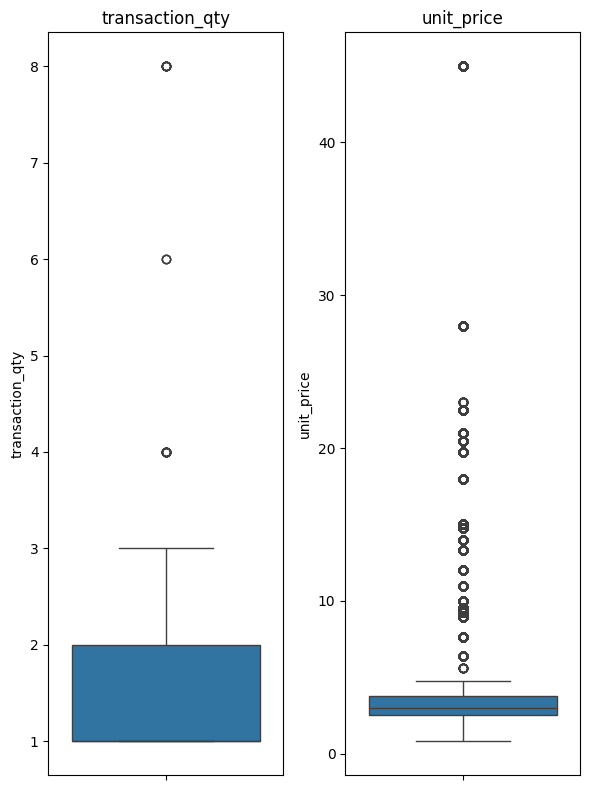

In [220]:
# Mostrar boxplot para detectar outliers en todas las columnas numéricas
plt.figure(figsize=(6, 8))
# Columnas especificas, ya que las demas que se encuentran en numeric_cols son ids
for i, col in enumerate(['transaction_qty','unit_price']):
  plt.subplot(1, 2, i + 1)
  sns.boxplot(y=df[col])
  plt.title(f'{col}')
plt.tight_layout()
plt.show()

## Ingenieria de datos

In [221]:
# Funcion para determinar el tiempo del dia
def time_of_day(x):
  if x < 12:
    return 'Morning'
  elif x < 17:
    return 'Afternoon'
  else:
    return 'Evening'

# Columna de la ganancia total, ya que en algunas transacciones se
# vende mas de una unidad
df['total'] = df['transaction_qty'] * df['unit_price']

# Columna del mes
df['mes_str'] = df['transaction_date'].dt.month_name()
print(df['mes_str'].value_counts().sort_index().head())

# Columna de semana (año-semana)
df['semana'] = df['transaction_date'].dt.to_period('W')
print(df['semana'].value_counts().sort_index().head())

# Columna del dia del mes
df['dia_num'] = df['transaction_date'].dt.day
print(df['dia_num'].value_counts().sort_index().head())

# Columna del dia de la semana (nombre)
df['dia_semana'] = df['transaction_date'].dt.day_name()
print(df['dia_semana'].value_counts().sort_index().head())

# Columna del dia de la semana (numero)
df['dia_semana_int'] = df['transaction_date'].dt.dayofweek
print(df['dia_semana_int'].value_counts().sort_index().head())

# Columna de tiempo del dia
df['time_of_day'] = df['transaction_time'].apply(lambda x: time_of_day(x.hour))
print(df['time_of_day'].value_counts().sort_index().head())

mes_str
April       25335
February    16359
January     17314
June        35352
March       21229
Name: count, dtype: int64
semana
2022-12-26/2023-01-01     550
2023-01-02/2023-01-08    3825
2023-01-09/2023-01-15    4113
2023-01-16/2023-01-22    4029
2023-01-23/2023-01-29    3854
Freq: W-SUN, Name: count, dtype: int64
dia_num
1    4787
2    4793
3    4928
4    4601
5    4741
Name: count, dtype: int64
dia_semana
Friday      21701
Monday      21643
Saturday    20510
Sunday      21096
Thursday    21654
Name: count, dtype: int64
dia_semana_int
0    21643
1    21202
2    21310
3    21654
4    21701
Name: count, dtype: int64
time_of_day
Afternoon    44427
Evening      22938
Morning      81751
Name: count, dtype: int64


In [222]:
# Columnas de aproximacion a un dia especial
# Con valor de 1 si es el dia especial, y mayor peso
# conforme este mas cerca
dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

############# FESTIVOS #############
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

dr = pd.date_range(start='2023-01-01', end='2023-12-31')
cal = calendar()
holidays = cal.holidays(start=dr.min(), end=dr.max())

def calcularProximidad(fecha):
    proximidad = min(abs((fecha - holiday).days) for holiday in holidays)
    if proximidad == 0:
        return 1
    elif proximidad == 1:
        return 0.95
    elif proximidad <= 7:
        return (1/proximidad) + 0.4
    elif proximidad <= 14:
        return (1/proximidad) + 0.3
    else:
        return 0

df['holiday_proximity'] = df['transaction_date'].apply(lambda x: calcularProximidad(x))
print(df['holiday_proximity'].value_counts().sort_index(ascending=False))

############# LUNES #############
def monday_proximity(dia):
  for i,day in enumerate(dias):
    if dia == day:
      return max([1 - 0.05 * i**2, 0])
  return 0

df['lunes_proximity'] = df['dia_semana'].apply(lambda x: monday_proximity(x))
print(df['lunes_proximity'].value_counts().sort_index(ascending=False))

holiday_proximity
1.000000     4070
0.950000     8087
0.900000     7254
0.733333     7594
0.650000     8548
0.600000     8601
0.566667     8557
0.542857     8257
0.425000     5008
0.411111     5270
0.400000     5601
0.390909     3043
0.383333     2707
0.376923     2899
0.371429     2713
0.000000    60907
Name: count, dtype: int64
lunes_proximity
1.00    21643
0.95    21202
0.80    21310
0.55    21654
0.20    21701
0.00    41606
Name: count, dtype: int64


In [223]:
# Funcion para retirar el detalle del producto
def clean_info(x):
  sizes = [' Rg', ' Lg', 'Sm']
  x = x.replace(sizes[0], '').replace(sizes[1], '').replace(sizes[2], '')
  return x.strip()

# Columna para el producto especifico, sin el detalle del tamaño
# (para ver las relaciones de producto claramente)
df['product'] = df['product_detail'].apply(lambda x: clean_info(x))
print(df['product'].value_counts().sort_index().head())

product
Almond Croissant       1903
Brazilian              8489
Brazilian - Organic     209
Cappuccino             5565
Carmel syrup           1725
Name: count, dtype: int64


In [9]:
# si es dia de trabajo
# si es fin de semana

# df['Is_weekend'] = df['transaction_date'].dt.weekday >= 5

# Agrupaciones

In [20]:
# Agrupaciones por semana
ventas_semana_tienda = df.groupby(['store_id', 'semana'])['total'].sum().reset_index()
ventas_semana = df.groupby(['semana'])['total'].sum().reset_index()
print(ventas_semana.head())

                  semana     total
0  2022-12-26/2023-01-01   2508.20
1  2023-01-02/2023-01-08  17139.33
2  2023-01-09/2023-01-15  19129.53
3  2023-01-16/2023-01-22  19818.51
4  2023-01-23/2023-01-29  18271.63


# Productos comprados frecuentemente
### Predictivo
### Predecir qué productos interesan más a los clientes
Analizar las compras de productos para identificar qué productos
tienen mayor popularidad. Detectar patrones de co-ocurrencia entre artículos y
generar sugerencias automáticas basadas en éxitos de ventas.

In [207]:
df_same_ticket =df[df.duplicated(subset=["transaction_date","transaction_time"], keep=False)]
transacciones = []
transaccion = []
sucursal = df_same_ticket["store_location"].iloc[0]
date = df_same_ticket["transaction_date"].iloc[0]
time = df_same_ticket["transaction_time"].iloc[0]
for ticket in df_same_ticket.iterrows():
  ticket = ticket[1]
  if ticket['transaction_date'] == date and ticket['transaction_time'] == time and ticket['store_location'] == sucursal:
      transaccion.append(ticket['product'])
  else:
      transacciones.append(transaccion)
      transaccion = []
      transaccion.append(ticket['product'])
      date = ticket['transaction_date']
      time = ticket['transaction_time']
      sucursal = ticket['store_location']

In [131]:
from apyori import apriori
reglas = apriori(transactions = transacciones, min_support = 0.003,
min_confidence = 0.2, min_lift = 3, min_length = 2, max_length = 2)
def inspect(resultados):
  lhs = [tuple(result[2][0][0])[0] for result in resultados]
  rhs = [tuple(result[2][0][1])[0] for result in resultados]
  supports = [result[1] for result in resultados]
  confidences = [result[2][0][2] for result in resultados]
  lifts = [result[2][0][3] for result in resultados]
  return list(zip(lhs, rhs, supports, confidences, lifts))

In [133]:
resultadosDataFrame = pd.DataFrame(inspect(list(reglas)),
columns = ['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])
resultadosDataFrame.nlargest(n = 10, columns = 'Lift')

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
8,Ginger Scone,Ouro Brasileiro shot,0.022765,0.305235,9.569312
9,Hazelnut syrup,Latte,0.023592,0.469079,4.243192
3,Cappuccino,Sugar Free Vanilla syrup,0.025511,0.236503,3.948948
1,Cappuccino,Chocolate syrup,0.023923,0.221779,3.874341
4,Carmel syrup,Espresso shot,0.011416,0.200581,3.863589
0,Cappuccino,Carmel syrup,0.022798,0.211350,3.713611
6,Chocolate syrup,Latte,0.022963,0.401156,3.628775
7,Espresso shot,Sugar Free Vanilla syrup,0.011250,0.216699,3.618267
5,Carmel syrup,Latte,0.022434,0.394186,3.565726
10,Latte,Sugar Free Vanilla syrup,0.022930,0.207423,3.463390


In [208]:
transacciones_cat = []
transaccion = []
sucursal = df_same_ticket["store_location"].iloc[0]
date = df_same_ticket["transaction_date"].iloc[0]
time = df_same_ticket["transaction_time"].iloc[0]
for ticket in df_same_ticket.iterrows():
  ticket = ticket[1]
  if ticket['transaction_date'] == date and ticket['transaction_time'] == time and ticket['store_location'] == sucursal:
      transaccion.append(ticket['product_category'])
  else:
      transacciones_cat.append(transaccion)
      transaccion = []
      transaccion.append(ticket['product_category'])
      date = ticket['transaction_date']
      time = ticket['transaction_time']
      sucursal = ticket['store_location']

In [209]:
from apyori import apriori
reglas_cat = apriori(transactions = transacciones_cat, min_support = 0.003,
min_confidence = 0.2, min_lift = 1.1, min_length = 2, max_length = 2)
def inspect(resultados):
  lhs = [tuple(result[2][0][0])[0] for result in resultados]
  rhs = [tuple(result[2][0][1])[0] for result in resultados]
  supports = [result[1] for result in resultados]
  confidences = [result[2][0][2] for result in resultados]
  lifts = [result[2][0][3] for result in resultados]
  return list(zip(lhs, rhs, supports, confidences, lifts))

In [210]:
resultadosDataFrame = pd.DataFrame(inspect(list(reglas_cat)),
                                   columns = ['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])
resultadosDataFrame

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,Drinking Chocolate,Bakery,0.066706,0.821516,1.194336
1,Bakery,Tea,0.264145,0.384020,1.178258
2,Branded,Tea,0.009463,0.382865,1.174715
3,Coffee,Flavours,0.223016,0.376473,1.682356
4,Coffee beans,Tea,0.020019,0.374613,1.149396
5,Loose Tea,Tea,0.013467,0.364369,1.117965
6,Packaged Chocolate,Tea,0.005923,0.379237,1.163585


/tmp/ipykernel_4319/3920416998.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


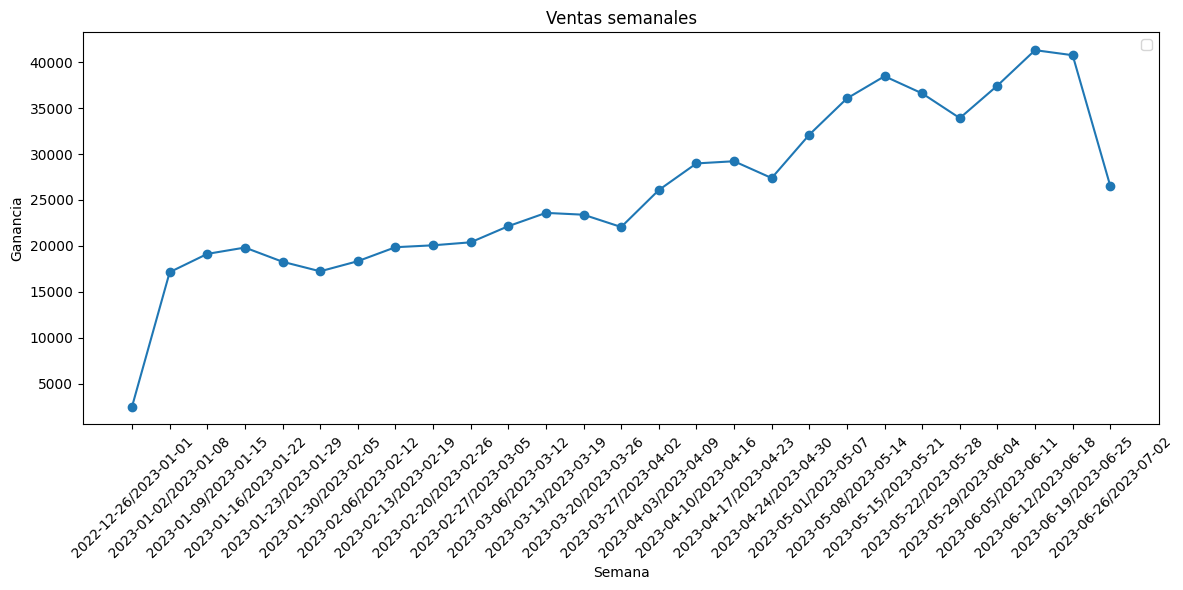

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(ventas_semana['semana'].astype(str), ventas_semana['total'], marker='o')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales")
plt.legend()

plt.tight_layout()
plt.show()

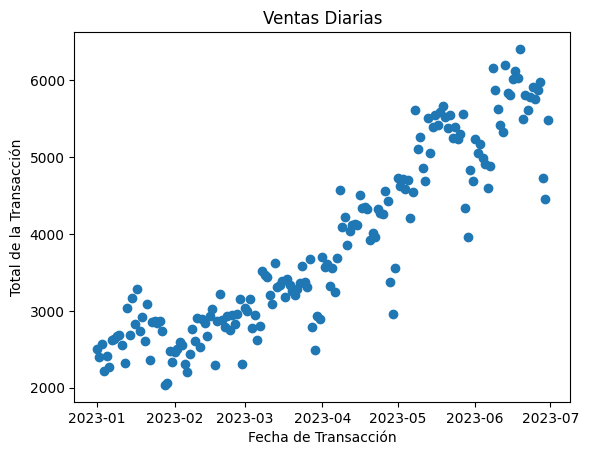

In [22]:
ventas_dia = df.groupby('transaction_date')['total'].sum().reset_index()

plt.scatter(ventas_dia['transaction_date'], ventas_dia['total'])
plt.xlabel('Fecha de Transacción')
plt.ylabel('Total de la Transacción')
plt.title('Ventas Diarias')
plt.show()

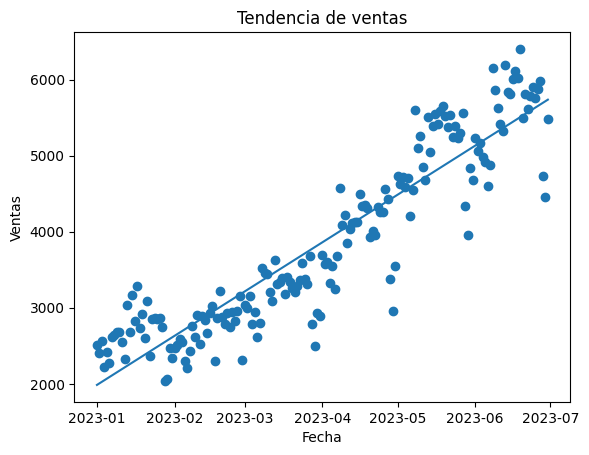

In [23]:
import numpy as np
df_daily = df.groupby('transaction_date')['total'].sum().reset_index()
# Convertir fechas a número
x = df_daily['transaction_date'].map(pd.Timestamp.toordinal)
y = df_daily['total']

# Regresión lineal
m, b = np.polyfit(x, y, 1)

# Línea de tendencia
y_pred = m * x + b

plt.scatter(df_daily['transaction_date'], y)
plt.plot(df_daily['transaction_date'], y_pred)

plt.title("Tendencia de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")

plt.show()

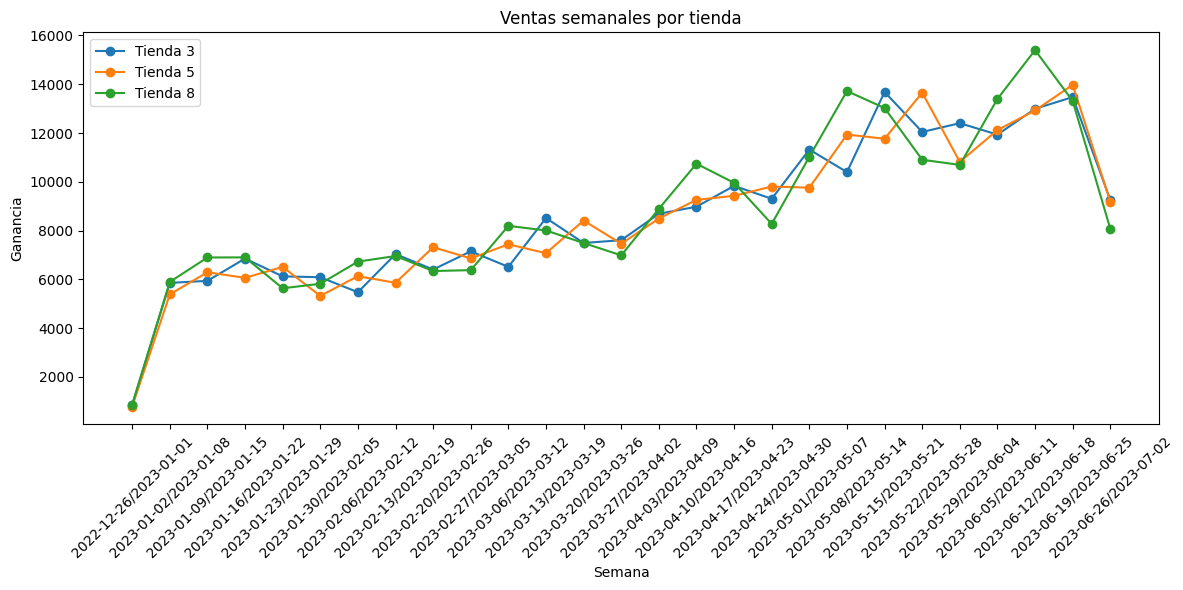

In [24]:
plt.figure(figsize=(12, 6))

for tienda in ventas_semana_tienda['store_id'].unique():
    data_tienda = ventas_semana_tienda[ventas_semana_tienda['store_id'] == tienda]

    plt.plot(data_tienda['semana'].astype(str),
             data_tienda['total'],
             marker='o',
             label=f'Tienda {tienda}')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales por tienda")
plt.legend()

plt.tight_layout()
plt.show()

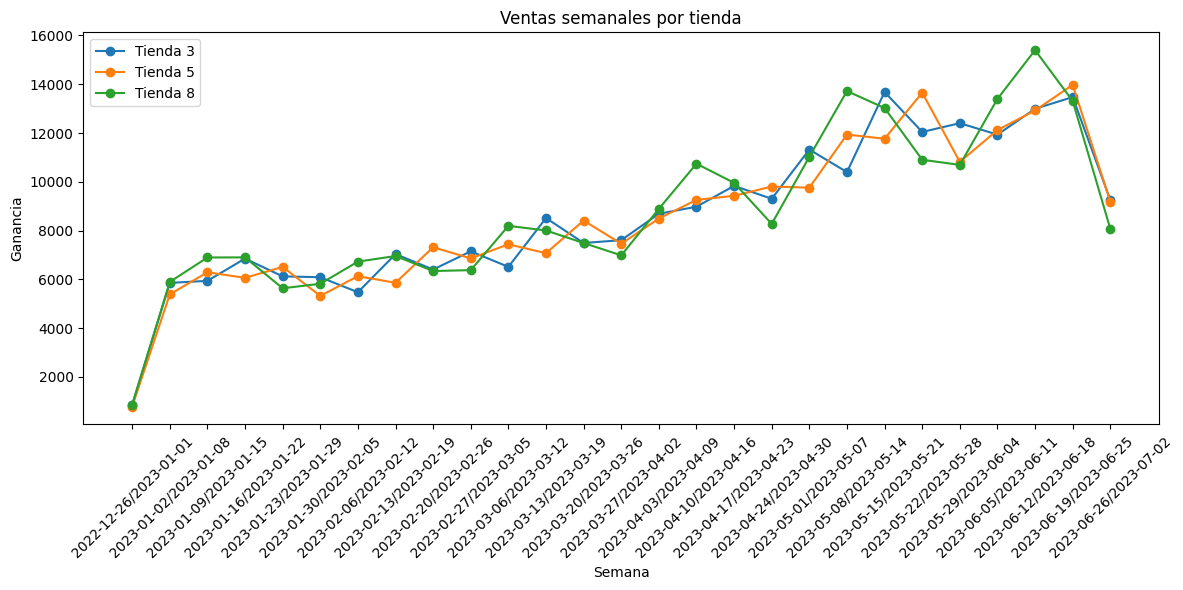

In [27]:
plt.figure(figsize=(12, 6))

for tienda in ventas_semana_tienda['store_id'].unique():
    data_tienda = ventas_semana_tienda[ventas_semana_tienda['store_id'] == tienda]

    plt.plot(data_tienda['semana'].astype(str),
             data_tienda['total'],
             marker='o',
             label=f'Tienda {tienda}')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales por tienda")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# Agrupacion por dias de la semana
ventas_dia_semana = df.groupby('dia_semana')['total'].mean().reset_index
print(ventas_dia_semana)

<bound method Series.reset_index of dia_semana
Friday       4.671352
Monday       4.697929
Saturday     4.724255
Sunday       4.661088
Thursday     4.653541
Tuesday      4.690875
Wednesday    4.707346
Name: total, dtype: float64>


In [29]:
# Convertir la columna 'transaction_time' a formato de hora y extraer las horas
df['num_hours'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df["num_hours"] = df["num_hours"].dt.hour

In [30]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=orden_dias, ordered=True)
ventas_dia = df.groupby(['dia_semana', 'semana'])['total'].sum().reset_index()

/tmp/ipykernel_4319/3320471527.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_dia = df.groupby(['dia_semana', 'semana'])['total'].sum().reset_index()


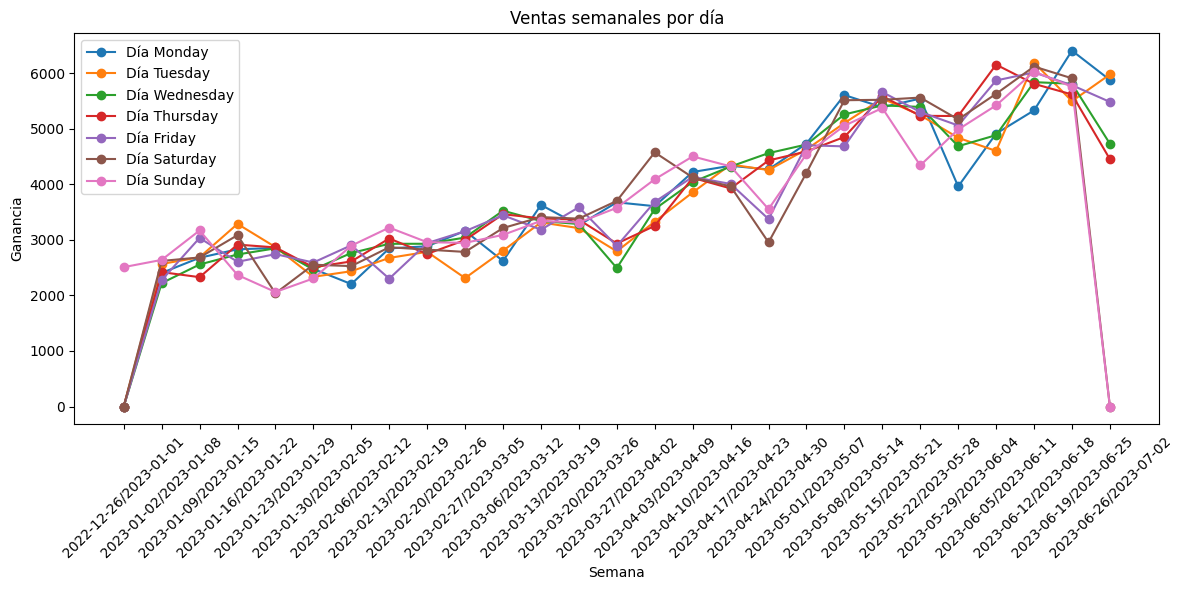

In [31]:
plt.figure(figsize=(12, 6))

for dia in ventas_dia['dia_semana'].unique():
    data_dia = ventas_dia[ventas_dia['dia_semana'] == dia]

    plt.plot(data_dia['semana'].astype(str),
             data_dia['total'],
             marker='o',
             label=f'Día {dia}')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales por día")
plt.legend()

plt.tight_layout()
plt.show()

# Ventas en cada sucursal
### Descriptivo
### Observar los éxitos en ventas de cada sucursal
Analizar frecuencia de ventas, ganancia, categorías preferidas y
tiempo de la compra para tratar de identificar a qué se debe el éxito de cada sucursal,
y si se puede replicar en las demás.

In [32]:
df['month'] = df['transaction_date'].dt.month
df['dia_semana'] = df['transaction_date'].dt.day_name()
df['num_hours'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

In [33]:
# Frecuencia de ventas por sucursal
transacciones_suc = df.groupby('store_location')['transaction_id'].count().reset_index()
transacciones_suc.columns = ['store_location', 'transacciones']
transacciones_suc['participacion_%'] = (transacciones_suc['transacciones'] / transacciones_suc['transacciones'].sum() * 100).round(2)
print(transacciones_suc)

    store_location  transacciones  participacion_%
0          Astoria          50599            33.93
1   Hell's Kitchen          50735            34.02
2  Lower Manhattan          47782            32.04


In [34]:
transacciones_suc_mes = df.groupby(['month', 'store_location'])['transaction_id'].count().reset_index()
transacciones_suc_mes.columns = ['month', 'store_location', 'transacciones']
print(transacciones_suc_mes)

    month   store_location  transacciones
0       1          Astoria           5913
1       1   Hell's Kitchen           5868
2       1  Lower Manhattan           5533
3       2          Astoria           5490
4       2   Hell's Kitchen           5606
5       2  Lower Manhattan           5263
6       3          Astoria           7180
7       3   Hell's Kitchen           7267
8       3  Lower Manhattan           6782
9       4          Astoria           8556
10      4   Hell's Kitchen           8629
11      4  Lower Manhattan           8150
12      5          Astoria          11475
13      5   Hell's Kitchen          11294
14      5  Lower Manhattan          10758
15      6          Astoria          11985
16      6   Hell's Kitchen          12071
17      6  Lower Manhattan          11296


In [35]:
# Ganancias totales por sucursal
ingresos_suc = df.groupby('store_location')['total'].sum().reset_index()
ingresos_suc.columns = ['store_location', 'ingresos']
ingresos_suc['participacion_%'] = (ingresos_suc['ingresos'] / ingresos_suc['ingresos'].sum() * 100).round(2)
print(ingresos_suc)

    store_location   ingresos  participacion_%
0          Astoria  232243.91            33.23
1   Hell's Kitchen  236511.17            33.84
2  Lower Manhattan  230057.25            32.92


In [36]:
# Ganancias por mes por sucursal
ingresos_suc_mes = df.groupby(['month', 'store_location'])['total'].sum().reset_index()
ingresos_suc_mes.columns = ['month', 'store_location', 'ingresos']
print(ingresos_suc_mes)

    month   store_location  ingresos
0       1          Astoria  27313.66
1       1   Hell's Kitchen  27820.65
2       1  Lower Manhattan  26543.43
3       2          Astoria  25105.34
4       2   Hell's Kitchen  25719.80
5       2  Lower Manhattan  25320.05
6       3          Astoria  32835.43
7       3   Hell's Kitchen  33110.57
8       3  Lower Manhattan  32888.68
9       4          Astoria  39477.61
10      4   Hell's Kitchen  40304.14
11      4  Lower Manhattan  39159.33
12      5          Astoria  52428.76
13      5   Hell's Kitchen  52598.93
14      5  Lower Manhattan  51700.07
15      6          Astoria  55083.11
16      6   Hell's Kitchen  56957.08
17      6  Lower Manhattan  54445.69


In [37]:
ticket_suc = ingresos_suc.copy()
ticket_suc['transacciones'] = transacciones_suc['transacciones']
ticket_suc['ticket_promedio'] = (ticket_suc['ingresos'] / ticket_suc['transacciones']).round(2)
ticket_suc

,store_location,ingresos,participacion_%,transacciones,ticket_promedio
0,Astoria,232243.91,33.23,50599,4.59
1,Hell's Kitchen,236511.17,33.84,50735,4.66
2,Lower Manhattan,230057.25,32.92,47782,4.81


In [38]:
ticket_max = ticket_suc['ticket_promedio'].max()
ticket_suc['ganancia_adicional'] = (ticket_max - ticket_suc['ticket_promedio']) * transacciones_suc['transacciones']
ticket_suc['ingresos_actuales'] = ingresos_suc['ingresos']
ticket_suc['ingresos_potenciales'] = ticket_suc['ingresos_actuales'] + ticket_suc['ganancia_adicional']
ticket_suc

,store_location,ingresos,participacion_%,transacciones,ticket_promedio,ganancia_adicional,ingresos_actuales,ingresos_potenciales
0,Astoria,232243.91,33.23,50599,4.59,11131.78,232243.91,243375.69
1,Hell's Kitchen,236511.17,33.84,50735,4.66,7610.25,236511.17,244121.42
2,Lower Manhattan,230057.25,32.92,47782,4.81,0.00,230057.25,230057.25


In [39]:
categorias_suc = df.groupby(['store_location', 'product_category'])['transaction_id'].count().reset_index()
categorias_suc.columns = ['store_location', 'product_category', 'transacciones']

total_por_suc = categorias_suc.groupby('store_location')['transacciones'].transform('sum')
categorias_suc['participacion_%'] = (categorias_suc['transacciones'] / total_por_suc * 100).round(2)

print(categorias_suc.sort_values(['store_location', 'transacciones'], ascending=[True, False]).to_string())

     store_location    product_category  transacciones  participacion_%
2           Astoria              Coffee          20025            39.58
8           Astoria                 Tea          16260            32.14
0           Astoria              Bakery           7289            14.41
4           Astoria  Drinking Chocolate           4300             8.50
5           Astoria            Flavours           1490             2.94
3           Astoria        Coffee beans            502             0.99
6           Astoria           Loose Tea            344             0.68
1           Astoria             Branded            279             0.55
7           Astoria  Packaged Chocolate            110             0.22
11   Hell's Kitchen              Coffee          20187            39.79
17   Hell's Kitchen                 Tea          15277            30.11
9    Hell's Kitchen              Bakery           7617            15.01
13   Hell's Kitchen  Drinking Chocolate           3763          

In [40]:
# Top 5 productos por sucursal
top_productos_suc = df.groupby(['store_location', 'product_type'])['transaction_id'].count().reset_index()
top_productos_suc.columns = ['store_location', 'product_type', 'transacciones']
top_productos_suc = top_productos_suc.sort_values(['store_location', 'transacciones'], ascending=[True, False])
top_productos_suc = top_productos_suc.groupby('store_location').head(5).reset_index(drop=True)
print(top_productos_suc)

     store_location           product_type  transacciones
0           Astoria        Brewed Chai tea           6293
1           Astoria  Gourmet brewed coffee           6053
2           Astoria       Barista Espresso           4930
3           Astoria          Hot chocolate           4300
4           Astoria      Brewed herbal tea           4008
5    Hell's Kitchen       Barista Espresso           6153
6    Hell's Kitchen        Brewed Chai tea           5824
7    Hell's Kitchen  Gourmet brewed coffee           5642
8    Hell's Kitchen          Hot chocolate           3763
9    Hell's Kitchen       Brewed Black tea           3760
10  Lower Manhattan       Barista Espresso           5320
11  Lower Manhattan  Gourmet brewed coffee           5217
12  Lower Manhattan        Brewed Chai tea           5066
13  Lower Manhattan       Brewed Black tea           3611
14  Lower Manhattan      Brewed herbal tea           3535


In [41]:
# Horas pico por sucursal
horas_suc = df.groupby(['store_location', 'num_hours'])['transaction_id'].count().reset_index()
horas_suc.columns = ['store_location', 'hora', 'transacciones']
top_horas_suc = horas_suc.sort_values(['store_location', 'transacciones'], ascending=[True, False])
top_horas_suc = top_horas_suc.groupby('store_location').head(5).reset_index(drop=True)
print(top_horas_suc)

compras_por_hora_suc = horas_suc.groupby('hora')['transacciones'].sum()
umbral_alto = compras_por_hora_suc.quantile(0.75)
horas_altas = compras_por_hora_suc[compras_por_hora_suc >= umbral_alto].index.tolist()
print(f"Horas de alta demanda (>= p75): {horas_altas}")

     store_location  hora  transacciones
0           Astoria    10           5291
1           Astoria     9           5083
2           Astoria     8           4966
3           Astoria     7           4181
4           Astoria    16           3599
5    Hell's Kitchen    10           6957
6    Hell's Kitchen     8           6909
7    Hell's Kitchen     9           6767
8    Hell's Kitchen    11           3598
9    Hell's Kitchen     7           3455
10  Lower Manhattan    10           6297
11  Lower Manhattan     9           5914
12  Lower Manhattan     7           5792
13  Lower Manhattan     8           5779
14  Lower Manhattan    15           3051
Horas de alta demanda (>= p75): [7, 8, 9, 10]


In [42]:
# Día de la semana con más ventas por sucursal
dias_suc = df.groupby(['store_location', 'dia_semana'])['total'].sum().reset_index()
dias_suc.columns = ['store_location', 'dia_semana', 'ingresos']
print(dias_suc.sort_values(['store_location', 'ingresos'], ascending=[True, False]).to_string())

     store_location dia_semana  ingresos
6           Astoria  Wednesday  34244.63
4           Astoria   Thursday  34140.37
1           Astoria     Monday  33928.29
0           Astoria     Friday  33472.75
3           Astoria     Sunday  32795.18
2           Astoria   Saturday  31845.93
5           Astoria    Tuesday  31816.76
12   Hell's Kitchen    Tuesday  34846.47
7    Hell's Kitchen     Friday  34743.18
13   Hell's Kitchen  Wednesday  33779.09
10   Hell's Kitchen     Sunday  33685.63
11   Hell's Kitchen   Thursday  33468.06
8    Hell's Kitchen     Monday  33389.51
9    Hell's Kitchen   Saturday  32599.23
15  Lower Manhattan     Monday  34359.48
18  Lower Manhattan   Thursday  33159.35
14  Lower Manhattan     Friday  33157.07
19  Lower Manhattan    Tuesday  32792.71
16  Lower Manhattan   Saturday  32449.32
20  Lower Manhattan  Wednesday  32289.82
17  Lower Manhattan     Sunday  31849.50


In [46]:
# Correlacion entre variables y ganancias por sucursal
import numpy as np
variables = ['num_hours', 'dia_semana_int', 'transaction_qty']

print("Correlacion con ganancias por sucursal:")
for suc in df['store_location'].unique():
    df_suc = df[df['store_location'] == suc]
    print(f"\n{suc}:")
    for var in variables:
        corr = np.corrcoef(df_suc[var], df_suc['total'])[0, 1]
        fuerza = "fuerte" if abs(corr) >= 0.7 else "moderada" if abs(corr) >= 0.4 else "débil"
        print(f"  {var} vs ganancias: {corr:.4f} ({fuerza})")

# num_hours vs ganancias: mide si la hora del día afecta cuánto gasta cada cliente por transacción.
#   Resultado débil (~0.00) — la hora no influye en el gasto por visita, los precios son fijos.
# weekday vs ganancias: mide si el día de la semana afecta las ganancias por transacción.
#   Resultado débil (~0.00) — el día tampoco influye en cuánto gasta cada cliente.
# transaction_qty vs ganancias: mide si comprar más productos genera más ganancias.
#   Resultado moderado en Lower Manhattan (0.44) y débil en las demás — en Lower Manhattan
#   los clientes que compran más productos tienden a gastar más, explicando su ticket promedio alto.

Correlacion con ganancias por sucursal:

Lower Manhattan:
  num_hours vs ganancias: -0.0302 (débil)
  dia_semana_int vs ganancias: -0.0045 (débil)
  transaction_qty vs ganancias: 0.4413 (moderada)

Hell's Kitchen:
  num_hours vs ganancias: -0.0107 (débil)
  dia_semana_int vs ganancias: -0.0028 (débil)
  transaction_qty vs ganancias: 0.3343 (débil)

Astoria:
  num_hours vs ganancias: 0.0086 (débil)
  dia_semana_int vs ganancias: 0.0046 (débil)
  transaction_qty vs ganancias: 0.3969 (débil)


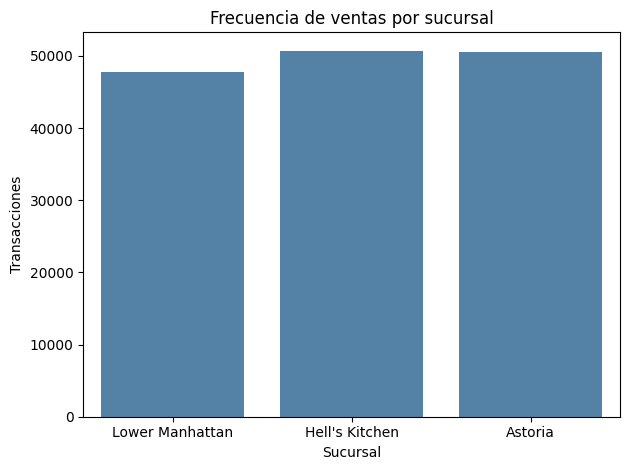

In [47]:
# Frecuencia de ventas por sucursal
sns.countplot(data=df, x='store_location', color='steelblue')
plt.title('Frecuencia de ventas por sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Transacciones')
plt.tight_layout()
plt.show()

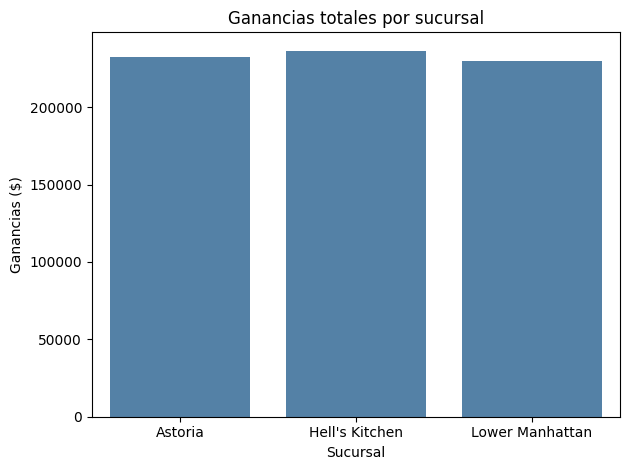

In [48]:
# Ganancias totales por sucursal
sns.barplot(data=ingresos_suc, x='store_location', y='ingresos', color='steelblue')
plt.title('Ganancias totales por sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Ganancias ($)')
plt.tight_layout()
plt.show()

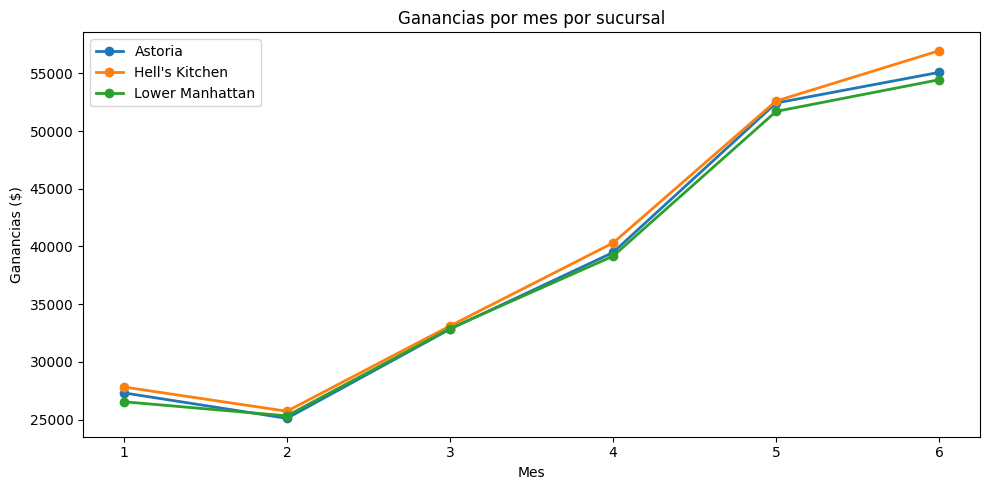

In [49]:
# Ganancias por mes por sucursal
plt.figure(figsize=(10, 5))
for suc in ingresos_suc_mes['store_location'].unique():
    data_suc = ingresos_suc_mes[ingresos_suc_mes['store_location'] == suc]
    plt.plot(data_suc['month'], data_suc['ingresos'], marker='o', label=suc, linewidth=2)

plt.title('Ganancias por mes por sucursal')
plt.xlabel('Mes')
plt.ylabel('Ganancias ($)')
plt.legend()
plt.tight_layout()
plt.show()

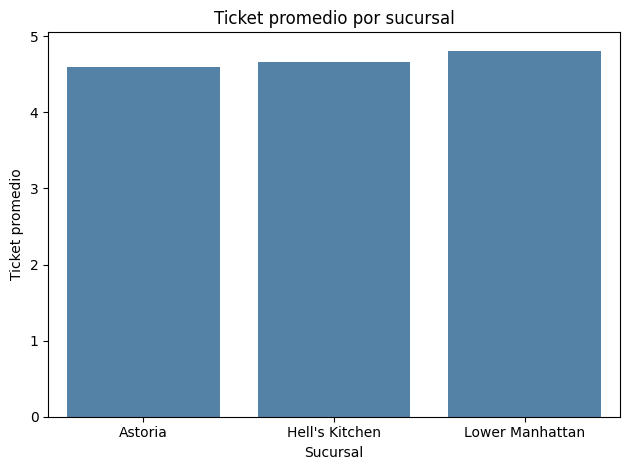

In [50]:
# Ticket promedio por sucursal
sns.barplot(data=ticket_suc, x='store_location', y='ticket_promedio', color='steelblue')
plt.title('Ticket promedio por sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Ticket promedio')
plt.tight_layout()
plt.show()

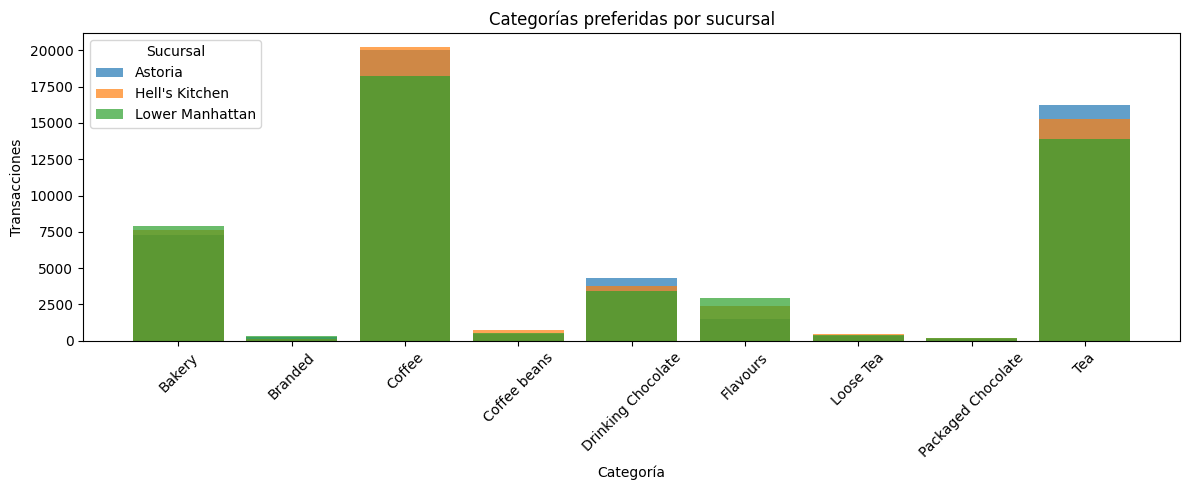

In [52]:
## HAY Q CAMBIAR ESTO POR LA GRAFICA DE LAS 3 BARRITAS UNA AL LADO DE OTRA
# Categorías preferidas por sucursal
plt.figure(figsize=(12, 5))
for suc in categorias_suc['store_location'].unique():
    data_suc = categorias_suc[categorias_suc['store_location'] == suc]
    plt.bar(data_suc['product_category'], data_suc['transacciones'], label=suc, alpha=0.7)

plt.title('Categorías preferidas por sucursal')
plt.xlabel('Categoría')
plt.ylabel('Transacciones')
plt.xticks(rotation=45)
plt.legend(title='Sucursal')
plt.tight_layout()
plt.show()

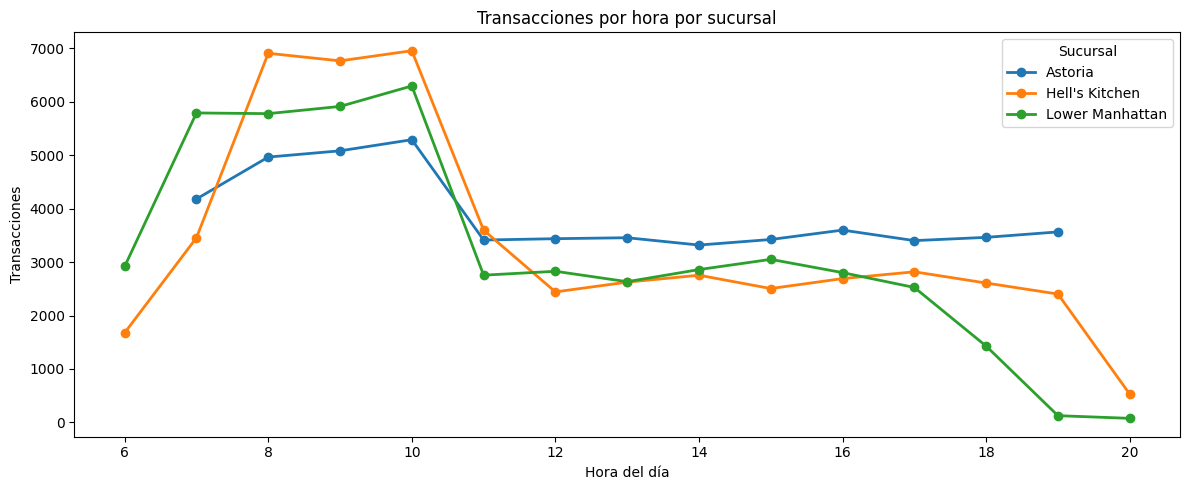

In [53]:
# Horas pico por sucursal
plt.figure(figsize=(12, 5))
for suc in horas_suc['store_location'].unique():
    data_suc = horas_suc[horas_suc['store_location'] == suc]
    plt.plot(data_suc['hora'], data_suc['transacciones'], marker='o', label=suc, linewidth=2)

plt.title('Transacciones por hora por sucursal')
plt.xlabel('Hora del día')
plt.ylabel('Transacciones')
plt.legend(title='Sucursal')
plt.tight_layout()
plt.show()

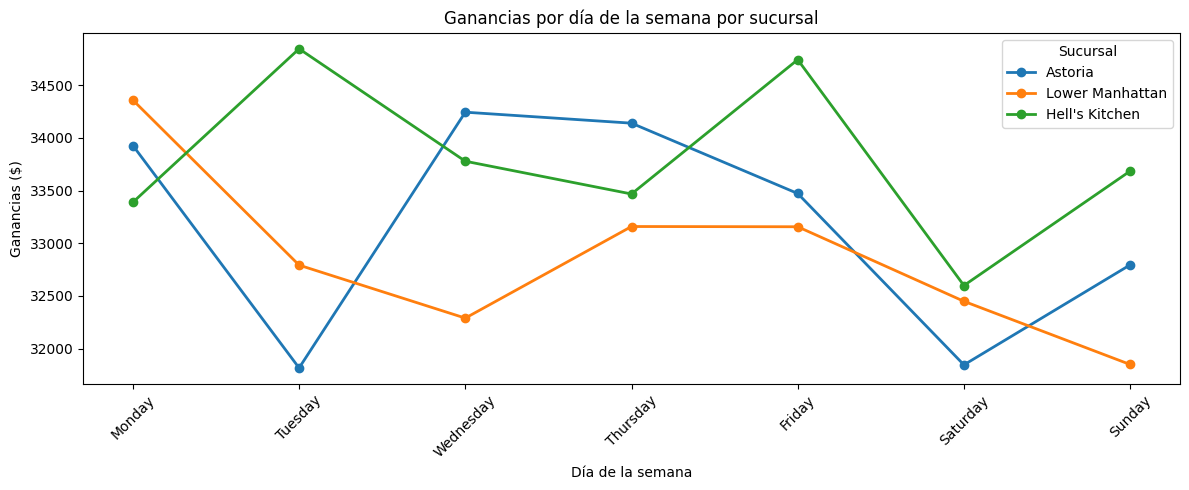

In [54]:
# Días de la semana por sucursal
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_suc['dia_semana'] = pd.Categorical(dias_suc['dia_semana'], categories=orden_dias, ordered=True)
dias_suc = dias_suc.sort_values('dia_semana')

plt.figure(figsize=(12, 5))
for suc in dias_suc['store_location'].unique():
    data_suc = dias_suc[dias_suc['store_location'] == suc]
    plt.plot(data_suc['dia_semana'], data_suc['ingresos'], marker='o', label=suc, linewidth=2)

plt.title('Ganancias por día de la semana por sucursal')
plt.xlabel('Día de la semana')
plt.ylabel('Ganancias ($)')
plt.xticks(rotation=45)
plt.legend(title='Sucursal')
plt.tight_layout()
plt.show()


**¿A qué se debe el éxito de cada sucursal?**

- **Hell's Kitchen** — Es la sucursal más exitosa en términos de transacciones (50,735) y ganancias (\$236,511.17). Su categoría dominante es Coffee y Tea, con pico de demanda a las 8:00h y mayores ganancias los martes ($34,870) y viernes (\$34,720). Su ticket promedio es de \$4.67.

- **Astoria** — segunda en transacciones (50,599) y ganancias (\$232,243.91). Comparte las mismas categorías preferidas que las demás (Coffee y Tea), pero su pico de demanda es de (9-10h), lo que indica una clientela con horarios distintos. Sus mejores días son miércoles y jueves. Ticket promedio de $4.59, el más bajo de las tres.

- **Lower Manhattan** — menor frecuencia de ventas (47,782 transacciones) y ganancias (\$230,057.25), pero compensa con el ticket promedio más alto (\$4.81), lo que indica que sus clientes gastan más por visita. Sus mejores días son lunes y martes, con pico a las 8:00h igual que Hell's Kitchen.

**¿Se puede replicar en las demás?**
Si Astoria y Hell's Kitchen igualaran el ticket promedio de Lower Manhattan (\$4.81 ):
- **Astoria** pasaría de \$232,243.91 a \$243,375.69 — una ganancia adicional de \$11,131.78
- **Hell's Kitchen** pasaría de \$236,511.17 a \$244,121.42 — una ganancia adicional de \$7,610.25

Esto sugiere que estrategias como promocionar productos de mayor valor podrían incrementar las ganancias sin necesitar más clientes, siendo Astoria la que más se beneficiaría al tener el ticket promedio más bajo (\$4.59).

# Ventas por temporada
### Descriptivo
### Observar los productos populares por temporada
Analizar la popularidad de los productos tomando como referencia
la fecha y posiblemente hora de la compra, esto para identificar qué productos se
deberían promocionar cerca de dicha fecha.

In [55]:
# Variables de tiempo necesarias
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['mes'] = df['transaction_date'].dt.month
df['mes_nombre'] = df['transaction_date'].dt.month_name()
df['quincena'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x <= 15 else 2)
df['num_hours'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['total'] = df['transaction_qty'] * df['unit_price']

In [56]:
# Top 5 productos más vendidos por mes
top_productos_mes = df.groupby(['mes_nombre', 'mes', 'product_type'])['transaction_qty'].sum().reset_index()
top_productos_mes = top_productos_mes.sort_values(['mes', 'transaction_qty'], ascending=[True, False])
top_productos_mes = top_productos_mes.groupby('mes_nombre').head(5).reset_index(drop=True)
print(top_productos_mes)

   mes_nombre  mes           product_type  transaction_qty
0     January    1  Gourmet brewed coffee             3018
1     January    1        Brewed Chai tea             3011
2     January    1       Barista Espresso             2861
3     January    1          Hot chocolate             2015
4     January    1       Brewed Black tea             2014
5    February    2        Brewed Chai tea             2853
6    February    2  Gourmet brewed coffee             2837
7    February    2       Barista Espresso             2747
8    February    2          Hot chocolate             1964
9    February    2       Brewed Black tea             1954
10      March    3        Brewed Chai tea             3750
11      March    3  Gourmet brewed coffee             3614
12      March    3       Barista Espresso             3560
13      March    3       Brewed Black tea             2508
14      March    3          Hot chocolate             2475
15      April    4        Brewed Chai tea             45

In [57]:
# Ventas por quincena (mediados vs fin de mes)
ventas_quincena = df.groupby(['mes', 'quincena'])['total'].sum().reset_index()
ventas_quincena['periodo'] = ventas_quincena['mes'].astype(str) + '-Q' + ventas_quincena['quincena'].astype(str)
print(ventas_quincena)

    mes  quincena     total periodo
0     1         1  38777.06    1-Q1
1     1         2  42900.68    1-Q2
2     2         1  39201.86    2-Q1
3     2         2  36943.33    2-Q2
4     3         1  47343.33    3-Q1
5     3         2  51491.35    3-Q2
6     4         1  57836.55    4-Q1
7     4         2  61104.53    4-Q2
8     5         1  73551.96    5-Q1
9     5         2  83175.80    5-Q2
10    6         1  81053.38    6-Q1
11    6         2  85432.50    6-Q2


In [58]:
# Productos más vendidos por hora
top_productos_hora = df.groupby(['num_hours', 'product_type'])['transaction_qty'].sum().reset_index()
top_productos_hora = top_productos_hora.sort_values(['num_hours', 'transaction_qty'], ascending=[True, False])
top_productos_hora = top_productos_hora.groupby('num_hours').head(3).reset_index(drop=True)
print(top_productos_hora)

    num_hours           product_type  transaction_qty
0           6        Brewed Chai tea              758
1           6       Barista Espresso              750
2           6  Gourmet brewed coffee              730
3           7       Barista Espresso             2321
4           7        Brewed Chai tea             2281
5           7  Gourmet brewed coffee             2143
6           8        Brewed Chai tea             3168
7           8  Gourmet brewed coffee             2952
8           8       Barista Espresso             2855
9           9  Gourmet brewed coffee             3077
10          9        Brewed Chai tea             2806
11          9       Barista Espresso             2685
12         10       Barista Espresso             3215
13         10        Brewed Chai tea             3160
14         10  Gourmet brewed coffee             3074
15         11  Gourmet brewed coffee             1784
16         11       Barista Espresso             1744
17         11        Brewed 

In [59]:
# Efecto de festivos en productos
ventas_festivos = df.groupby(['Holiday_proximity', 'product_type'])['transaction_qty'].sum().reset_index()
ventas_festivos = ventas_festivos[ventas_festivos['Holiday_proximity'] > 0]
ventas_festivos = ventas_festivos.sort_values('transaction_qty', ascending=False) #.head(10)
print(ventas_festivos)

     Holiday_proximity           product_type  transaction_qty
272           0.566667  Gourmet brewed coffee             1649
330           0.650000  Gourmet brewed coffee             1566
321           0.650000        Brewed Chai tea             1549
243           0.542857  Gourmet brewed coffee             1542
292           0.600000        Brewed Chai tea             1538
..                 ...                    ...              ...
71            0.376923            Green beans                2
186           0.411111            Green beans                1
44            0.371429              Green tea                1
129           0.390909              Green tea                1
106           0.383333      Organic Chocolate                1

[433 rows x 3 columns]


In [60]:
ventas_dia_clima = df.groupby('transaction_date').agg({'total': 'sum', 'TAVG': 'mean'}).reset_index()
ventas_dia_clima['TAVG_C'] = ((ventas_dia_clima['TAVG'] - 32) * 5/9).round(1)  # <- agrega esta
print(ventas_dia_clima[['transaction_date', 'total', 'TAVG_C']])
print("\nCorrelación temperatura vs ventas diarias:")
print(ventas_dia_clima[['TAVG_C', 'total']].corr())

KeyError: "Column(s) ['TAVG'] do not exist"

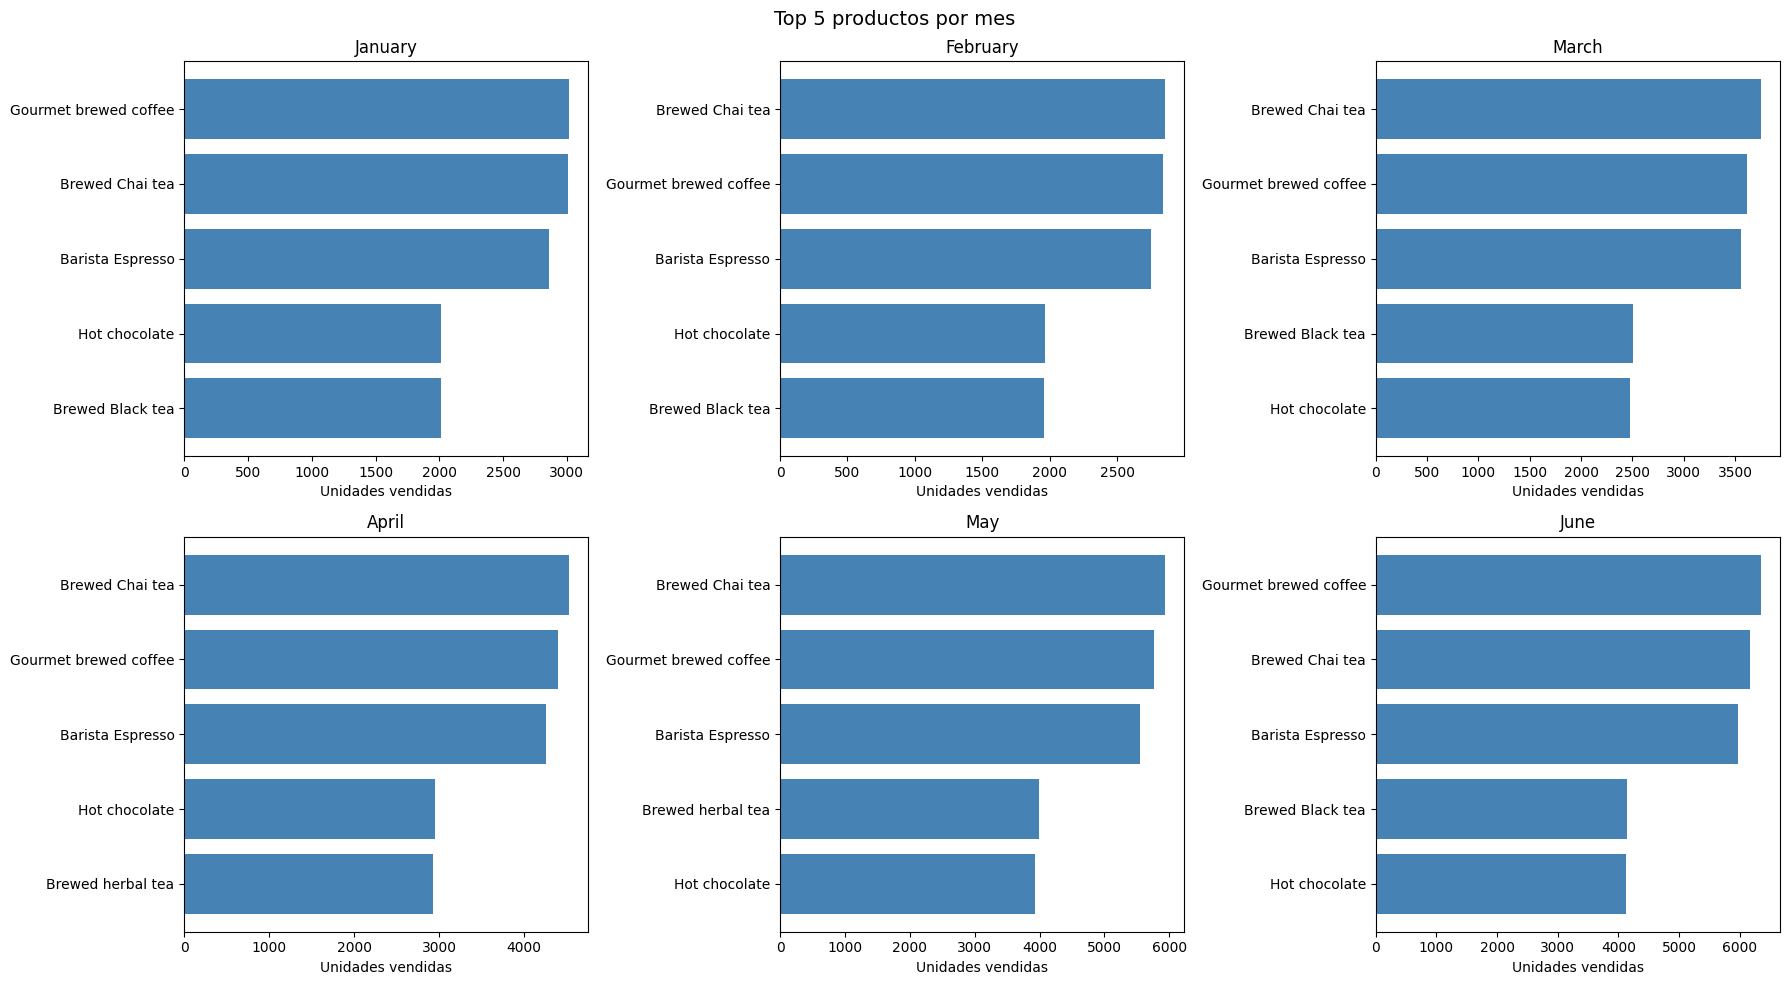

In [61]:
# Top 5 productos por mes
orden_meses = ['January','February','March','April','May','June']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, mes in enumerate(orden_meses):
    data_mes = top_productos_mes[top_productos_mes['mes_nombre'] == mes]
    axes[i].barh(data_mes['product_type'], data_mes['transaction_qty'], color='steelblue')
    axes[i].set_title(mes)
    axes[i].set_xlabel('Unidades vendidas')
    axes[i].invert_yaxis()

plt.suptitle('Top 5 productos por mes', fontsize=14)
plt.tight_layout()
plt.show()

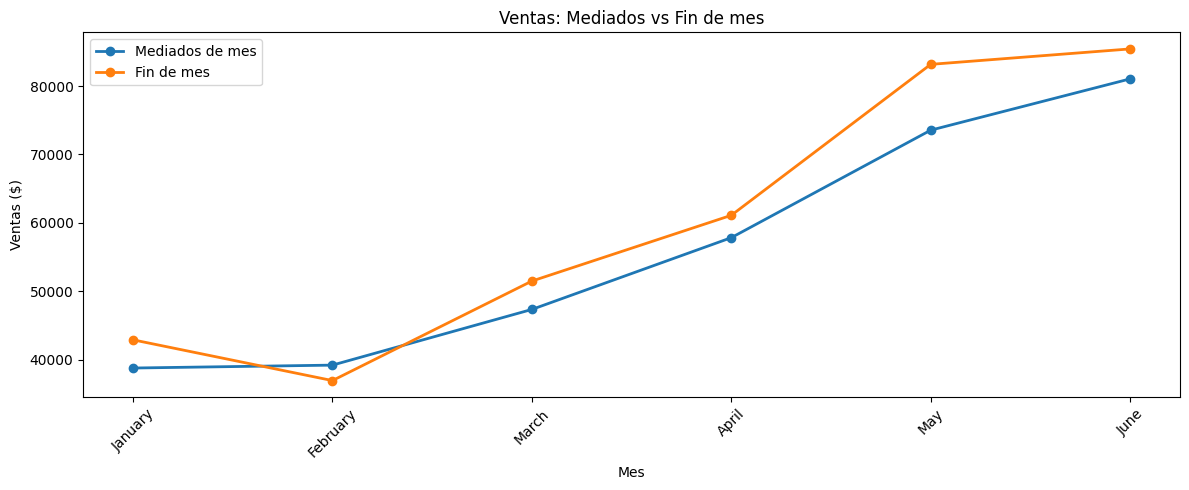

In [62]:
# Ventas por quincena
plt.figure(figsize=(12, 5))
for q in [1, 2]:
    data_q = ventas_quincena[ventas_quincena['quincena'] == q]
    plt.plot(data_q['mes'], data_q['total'], marker='o',
             label=f'{"Mediados" if q == 1 else "Fin"} de mes', linewidth=2)

plt.xticks(range(1, 7), orden_meses, rotation=45)
plt.xlabel('Mes')
plt.ylabel('Ventas ($)')
plt.title('Ventas: Mediados vs Fin de mes')
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# Temperatura vs ventas diarias
ventas_dia = df.groupby('transaction_date').agg({'total': 'sum', 'TAVG': 'mean'}).reset_index()
ventas_dia['TAVG_C'] = ((ventas_dia['TAVG'] - 32) * 5/9).round(1)

plt.figure(figsize=(10, 5))
plt.scatter(ventas_dia['TAVG_C'], ventas_dia['total'], alpha=0.5, color='steelblue')

m, b = np.polyfit(ventas_dia['TAVG_C'].dropna(),
                  ventas_dia.loc[ventas_dia['TAVG_C'].notna(), 'total'], 1)
x_vals = ventas_dia['TAVG_C'].dropna().sort_values()
plt.plot(x_vals, m * x_vals + b, color='red', linewidth=2, label='Tendencia')

plt.xlabel('Temperatura promedio del día (°C)')
plt.ylabel('Ventas del día ($)')
plt.title('Relación entre temperatura y ventas diarias')
plt.legend()
plt.tight_layout()
plt.show()

KeyError: "Column(s) ['TAVG'] do not exist"

In [ ]:
# Productos más vendidos cerca de festivos
plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_festivos, x='transaction_qty', y='product_type', color='steelblue')
plt.title('Top productos vendidos cerca de días festivos')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

## Resultados del Analisis
### Productos populares por mes
El top 3 se mantiene constante durante todos los meses: Brewed Chai tea, Gourmet brewed coffee y Barista Espresso.

### Ventas: Mediados vs Fin de mes
Los datos muestran que a fin de mes supera a mediados de la mayoría de los meses, con excepción de febrero donde mediados fue ligeramente mayor.

### Efecto de la temperatura en ventas
La gráfica muestra una correlación positiva entre temperatura y ventas diarias. En días fríos (bajo 0°C) las ventas rondan los \$2,000-\$2,500, mientras que en días cálidos (20-27°C) alcanzan los \$5,000-\$6,000. Esto sugiere que el clima impacta directamente el tráfico de clientes, posiblemente porque en días fríos hay menos gente en la calle en Nueva York, Manhattan.

### Productos cerca de días festivos
Durante fechas cercanas a días festivos, los tres productos más vendidos son Gourmet brewed coffee (\~1,600 unidades), Brewed Chai tea (\~1,540 unidades) y Barista Espresso (\~1,490 unidades).

### Conclusión
- Promocionar Brewed Chai tea de febrero a mayo, y Gourmet brewed coffee en enero y junio.
- Lanzar promociones en fin de mes para mantener el impulso de ventas.
- En días con pronóstico de frío, considerar promociones para **incentivar visitas** ya que el tráfico tiende a bajar.
- En fechas festivas, destacar Gourmet brewed coffee y Brewed Chai tea como productos estrella.

# Horarios pico
### Descriptivo
### Identificar las horas con mayor concurrencia de clientes y volúmenes de ventas.
Analizar las ventas a lo largo del día para identificar en qué horas
se concentra la mayor cantidad de transacciones. Evaluar la frecuencia de compras
y el volumen de ingresos por hora para detectar patrones de comportamiento de los
clientes y determinar los horarios de mayor actividad.

In [64]:
heatmap_data = df.pivot_table(
    values='total',
    index='store_id',
    columns='num_hours',
    aggfunc='count'
)

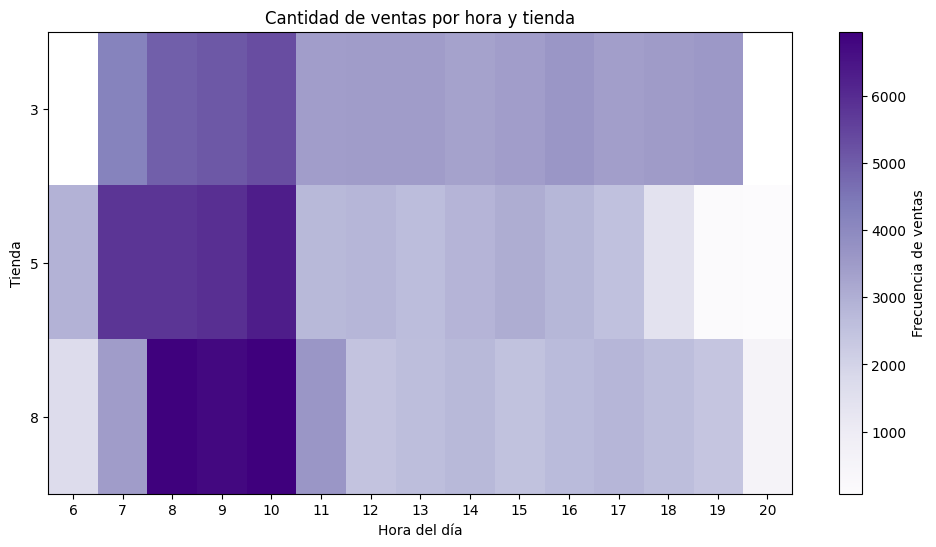

In [65]:
plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect='auto', cmap='Purples')

plt.colorbar(label='Frecuencia de ventas')

# Etiquetas
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

plt.xlabel("Hora del día")
plt.ylabel("Tienda")
plt.title("Cantidad de ventas por hora y tienda")

plt.show()

In [66]:
heatmap_data = df.pivot_table(
    values='total',
    index='product_type',
    columns='num_hours',
    aggfunc='count'
)

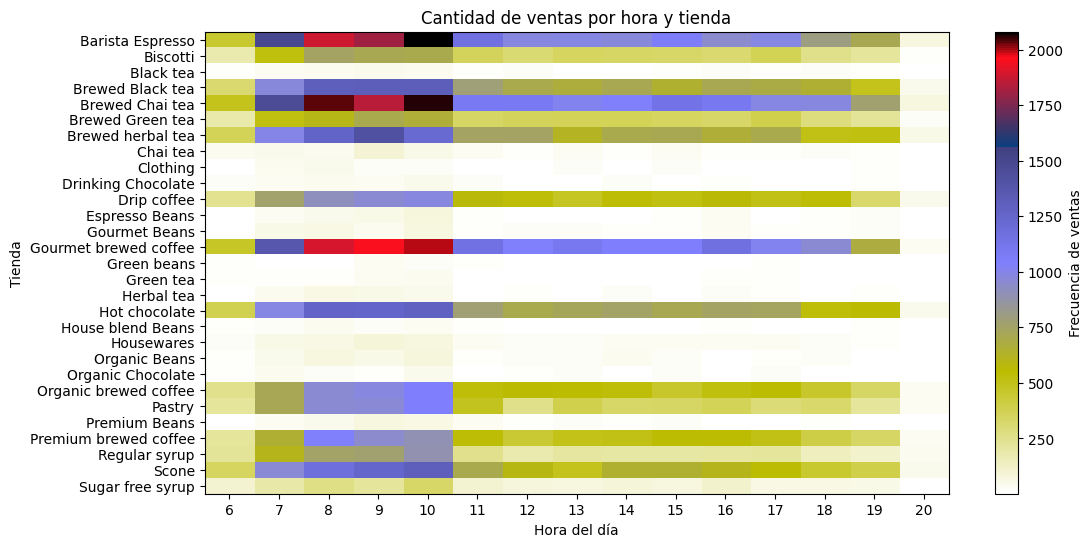

In [67]:
plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect='auto', cmap='gist_stern_r')

plt.colorbar(label='Frecuencia de ventas')

# Etiquetas
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

plt.xlabel("Hora del día")
plt.ylabel("Tienda")
plt.title("Cantidad de ventas por hora y tienda")

plt.show()

In [68]:
heatmap_data = df.pivot_table(
    values='total',
    index='dia_semana',
    columns='num_hours',
    aggfunc='sum'
)

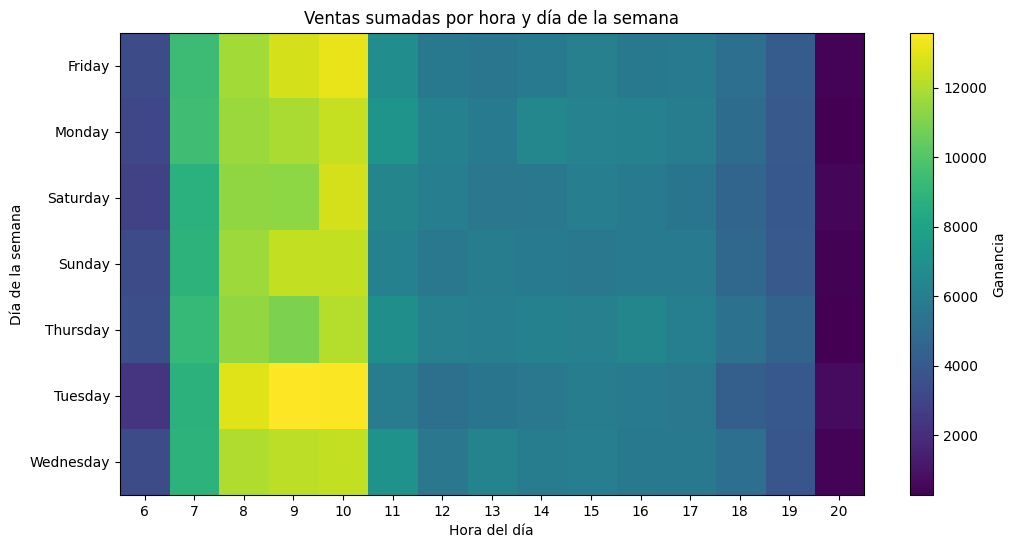

In [69]:
plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect='auto')

plt.colorbar(label='Ganancia')

# Etiquetas
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Ventas sumadas por hora y día de la semana")

plt.show()

In [70]:
heatmap_data = df.pivot_table(
    values='total',
    index='dia_semana',
    columns='num_hours',
    aggfunc='count'  # mean para promedio, count para cantidad de ventas
)

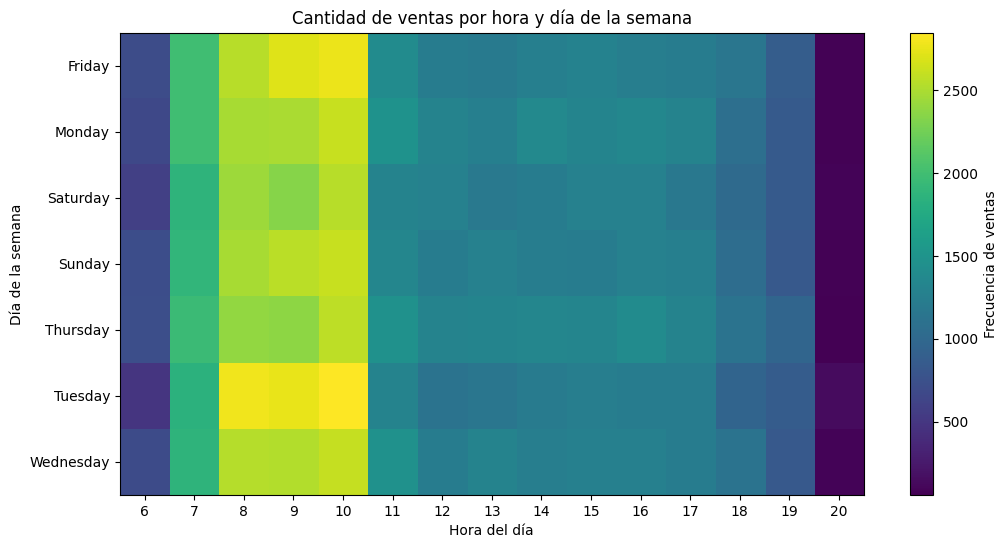

In [71]:
plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect='auto')

plt.colorbar(label='Frecuencia de ventas')

# Etiquetas
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Cantidad de ventas por hora y día de la semana")

plt.show()

In [72]:
import pandas as pd

# Asegurar formato de fecha
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Crear variables de tiempo
df['dia_semana'] = df['transaction_date'].dt.dayofweek
df['mes'] = df['transaction_date'].dt.month
df['hora'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['nday'] = df['transaction_date'].dt.day
df['quincena'] = df['nday'].apply(lambda x: 1 if x <= 15 else 2)

X = df[['dia_semana', 'hora', 'quincena']]
y = df['total']

train = df[df['transaction_date'].dt.month <= 5]
test = df[df['transaction_date'].dt.month == 6]

X_train = train[['dia_semana', 'hora']]
y_train = train['total']

X_test = test[['dia_semana', 'hora']]
y_test = test['total']

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [74]:
y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.9665803839312832
RMSE: 23.874616062872086


In [76]:
print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)

Intercepto: 4.899583161454228
Coeficientes: [-0.00744222 -0.01690243]


In [81]:
# Predecir top 5 productos
data_dummies = pd.get_dummies(df, columns=['product_category', 'product_type', 'product_detail', 'dia_semana_int', 'month', 'time_of_day'])

data_dummies.drop(['transaction_time', 'unit_price', 'store_location'], axis=1, inplace=True)
data_dummies['transaction_date'] = pd.to_datetime(data_dummies['transaction_date'])

data_daily = data_dummies.groupby('transaction_date').sum(numeric_only=True).reset_index()

data_daily['nday'] = data_daily['transaction_date'].dt.day


data_daily


,transaction_date,transaction_id,transaction_qty,store_id,product_id,total,dia_num,dia_semana,Holiday_proximity,Lunes_proximity,...,dia_semana_int_6,month_1,month_2,month_3,month_4,month_5,month_6,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning
0,2023-01-01,151525,802,2922,25406,2508.20,550,3300,522.500000,385.00,...,550,550,0,0,0,0,0,256,138,156
1,2023-01-02,471761,790,2991,26332,2403.35,1132,0,566.000000,566.00,...,0,566,0,0,0,0,0,281,131,154
2,2023-01-03,819165,823,3133,27579,2565.00,1746,582,552.900000,552.90,...,0,582,0,0,0,0,0,287,134,161
3,2023-01-04,967659,726,2621,22629,2220.10,1988,994,447.300000,447.30,...,0,497,0,0,0,0,0,241,136,120
4,2023-01-05,1350543,778,2843,25757,2418.85,2735,1641,401.133333,464.95,...,0,547,0,0,0,0,0,278,113,156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,2023-06-26,172562780,1837,6272,56456,5875.90,31070,0,648.714286,1195.00,...,0,0,0,0,0,0,1195,336,183,676
177,2023-06-27,185982280,1962,6785,61984,5975.65,34479,1277,693.228571,1213.15,...,0,0,0,0,0,0,1277,344,199,734
178,2023-06-28,157090445,1531,5566,49848,4728.90,29960,2140,606.333333,963.00,...,0,0,0,0,0,0,1070,446,205,419
179,2023-06-29,149183677,1429,5107,48636,4450.75,29261,3027,605.400000,857.65,...,0,0,0,0,0,0,1009,436,208,365


In [82]:
import matplotlib.pyplot as plt

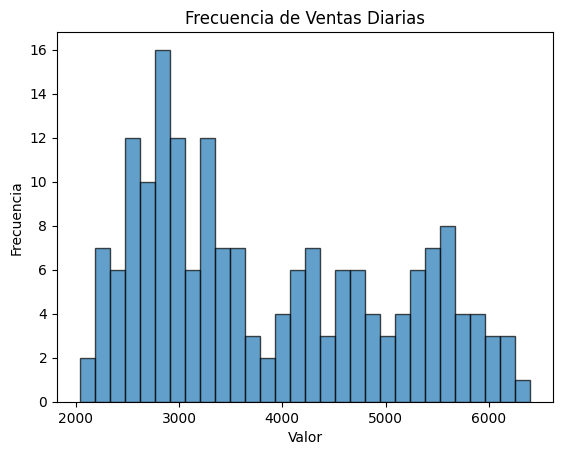

In [83]:
# Crear el histograma
plt.hist(data_daily['total'], bins=30, edgecolor='black', alpha=0.7)

plt.title('Frecuencia de Ventas Diarias')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

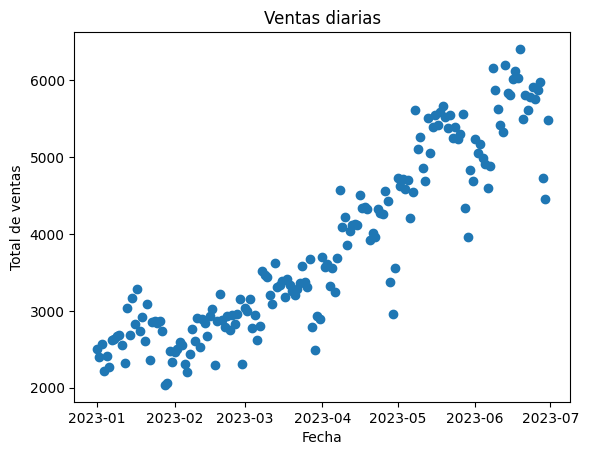

In [84]:

data_daily = data_daily.sort_values('transaction_date', ascending=False)

plt.scatter(data_daily['transaction_date'], data_daily['total'])
plt.xlabel('Fecha')
plt.ylabel('Total de ventas')
plt.title('Ventas diarias')
plt.show()

In [85]:
data_daily.sum().reset_index()
data_train = data_daily[data_dummies['month_June'] == 0]
data_test = data_daily[data_dummies['month_June'] == 1]

X = data_train.drop(['total','transaction_time','store_location','nday','product_detail'], axis=1)
ventaTotal = data_train['total']
X_test = data_test.drop(['total','transaction_date','transaction_time','store_location','nday'], axis=1)
ventaTotal_test = data_test['total']

TypeError: 'DatetimeArray' with dtype datetime64[ns] does not support reduction 'sum'

In [86]:
from sklearn.linear_model import LinearRegression
modelo_venta = LinearRegression()
modelo_venta.fit(X, ventaTotal)

NameError: name 'ventaTotal' is not defined

In [ ]:
ventaTotal_pred = modelo_venta.predict(X_test)

In [ ]:
ventaTotal_pred
data_test['nday'].values

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data_test['nday'].values, ventaTotal_pred, marker = "o") #Dibuja una línea uniendo los puntos (x,y)
plt.plot(data_test['nday'].values, ventaTotal_test, marker = "x")

plt.show()